In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [6]:
df = pd.read_csv(r"D:\chicago-taxi-fare-prediction\chicago_taxi_train.csv")

In [7]:
df

,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.00,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.00,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.00,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.00,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.00,0.0,0.0,0.0,10.00,Cash,Flash Cab
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31689,05/17/2022 1:15:00 PM,05/17/2022 1:30:00 PM,13.25,739,13.06,63.6,NaN,NaN,75.0,28.0,32.50,0.00,0.0,0.0,0.0,32.50,Prcard,Blue Ribbon Taxi Association
31690,05/17/2022 9:45:00 PM,05/17/2022 10:15:00 PM,21.75,1740,30.90,63.9,NaN,NaN,76.0,NaN,44.50,10.00,13.9,0.0,27.5,82.00,Credit Card,Choice Taxi Association
31691,05/18/2022 3:45:00 AM,05/18/2022 4:00:00 AM,3.75,687,12.21,64.0,NaN,NaN,22.0,NaN,30.75,0.00,0.0,0.0,0.0,30.75,Prcard,Sun Taxi
31692,05/16/2022 2:45:00 PM,05/16/2022 3:30:00 PM,14.75,2040,36.60,64.6,NaN,NaN,76.0,7.0,41.75,11.55,25.2,0.0,4.0,57.30,Credit Card,"Taxicab Insurance Agency, LLC"


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31694 entries, 0 to 31693
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TRIP_START_TIMESTAMP    31694 non-null  object 
 1   TRIP_END_TIMESTAMP      31694 non-null  object 
 2   TRIP_START_HOUR         31694 non-null  float64
 3   TRIP_SECONDS            31694 non-null  int64  
 4   TRIP_MILES              31694 non-null  float64
 5   TRIP_SPEED              31694 non-null  float64
 6   PICKUP_CENSUS_TRACT     13259 non-null  float64
 7   DROPOFF_CENSUS_TRACT    14023 non-null  float64
 8   PICKUP_COMMUNITY_AREA   28477 non-null  float64
 9   DROPOFF_COMMUNITY_AREA  28199 non-null  float64
 10  FARE                    31694 non-null  float64
 11  TIPS                    31694 non-null  float64
 12  TIP_RATE                31694 non-null  float64
 13  TOLLS                   31694 non-null  float64
 14  EXTRAS                  31694 non-null

In [9]:
df.isnull().sum()

TRIP_START_TIMESTAMP          0
TRIP_END_TIMESTAMP            0
TRIP_START_HOUR               0
TRIP_SECONDS                  0
TRIP_MILES                    0
TRIP_SPEED                    0
PICKUP_CENSUS_TRACT       18435
DROPOFF_CENSUS_TRACT      17671
PICKUP_COMMUNITY_AREA      3217
DROPOFF_COMMUNITY_AREA     3495
FARE                          0
TIPS                          0
TIP_RATE                      0
TOLLS                         0
EXTRAS                        0
TRIP_TOTAL                    0
PAYMENT_TYPE                  0
COMPANY                       0
dtype: int64

In [10]:
df = df.drop(columns=['PICKUP_CENSUS_TRACT','DROPOFF_CENSUS_TRACT'])

In [11]:
df['PICKUP_COMMUNITY_AREA'] = df['PICKUP_COMMUNITY_AREA'].fillna(
    df['PICKUP_COMMUNITY_AREA'].median()
)

df['DROPOFF_COMMUNITY_AREA'] = df['DROPOFF_COMMUNITY_AREA'].fillna(
    df['DROPOFF_COMMUNITY_AREA'].median()
)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31694 entries, 0 to 31693
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TRIP_START_TIMESTAMP    31694 non-null  object 
 1   TRIP_END_TIMESTAMP      31694 non-null  object 
 2   TRIP_START_HOUR         31694 non-null  float64
 3   TRIP_SECONDS            31694 non-null  int64  
 4   TRIP_MILES              31694 non-null  float64
 5   TRIP_SPEED              31694 non-null  float64
 6   PICKUP_COMMUNITY_AREA   31694 non-null  float64
 7   DROPOFF_COMMUNITY_AREA  31694 non-null  float64
 8   FARE                    31694 non-null  float64
 9   TIPS                    31694 non-null  float64
 10  TIP_RATE                31694 non-null  float64
 11  TOLLS                   31694 non-null  float64
 12  EXTRAS                  31694 non-null  float64
 13  TRIP_TOTAL              31694 non-null  float64
 14  PAYMENT_TYPE            31694 non-null

In [13]:
df.duplicated().sum()

1

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

0

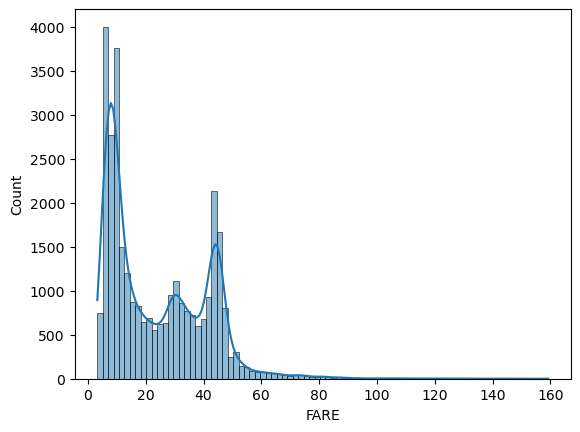

In [16]:
sns.histplot(df['FARE'], kde=True)
plt.show()

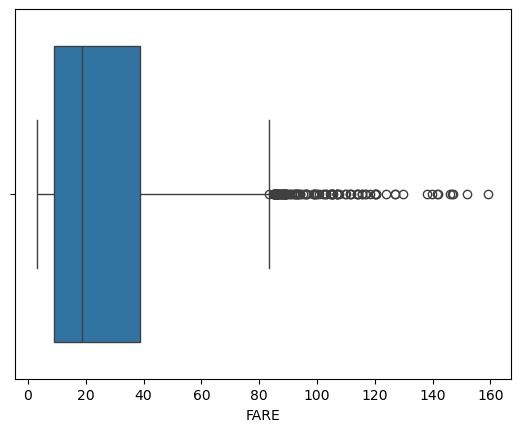

In [17]:
sns.boxplot(x=df['FARE'])
plt.show()

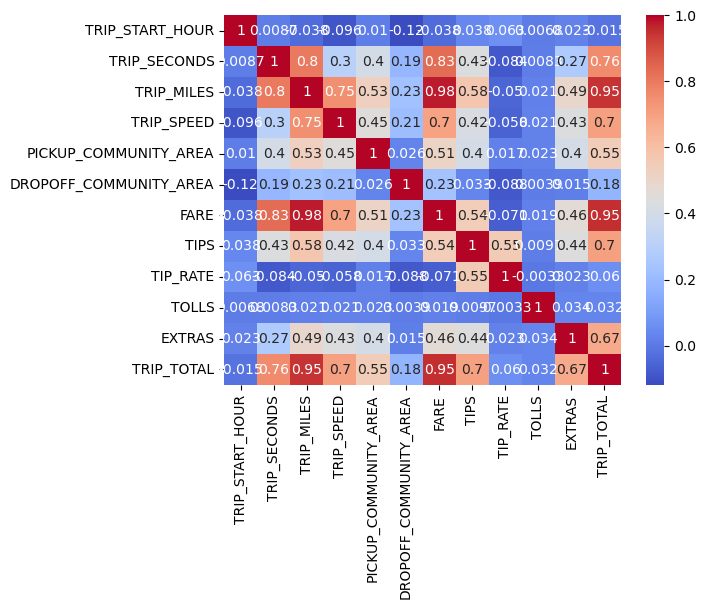

In [18]:
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

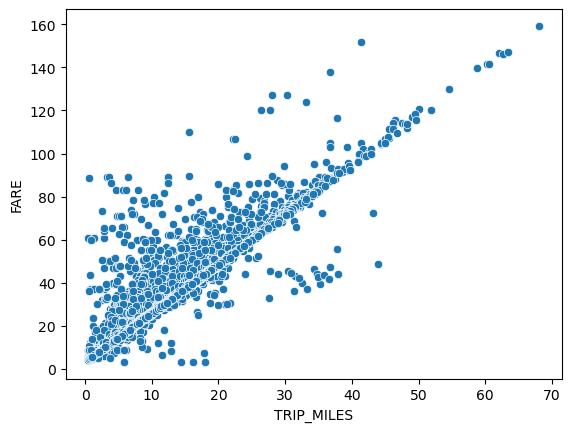

In [19]:
sns.scatterplot(
    x='TRIP_MILES',
    y='FARE',
    data=df
)
plt.show()

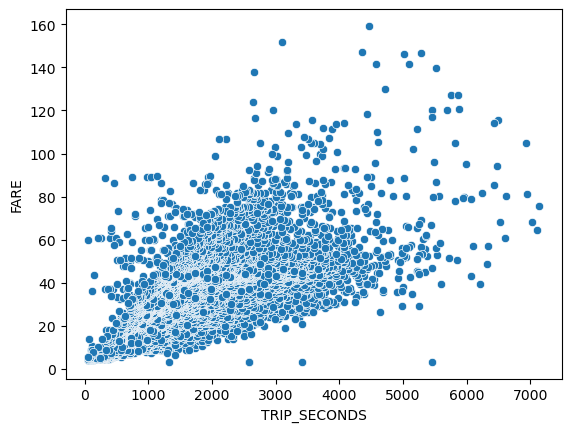

In [20]:
sns.scatterplot(
    x='TRIP_SECONDS',
    y='FARE',
    data=df
)
plt.show()

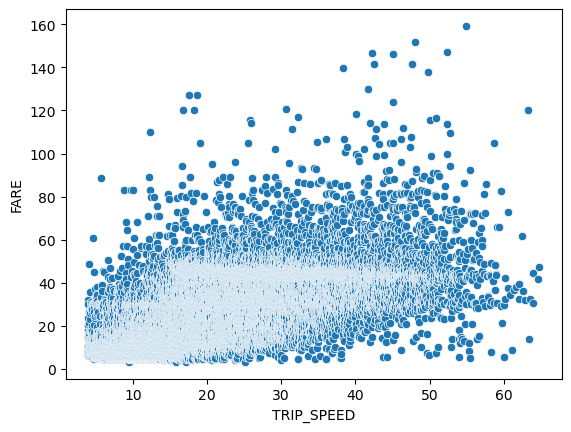

In [21]:
sns.scatterplot(
    x='TRIP_SPEED',
    y='FARE',
    data=df
)
plt.show()

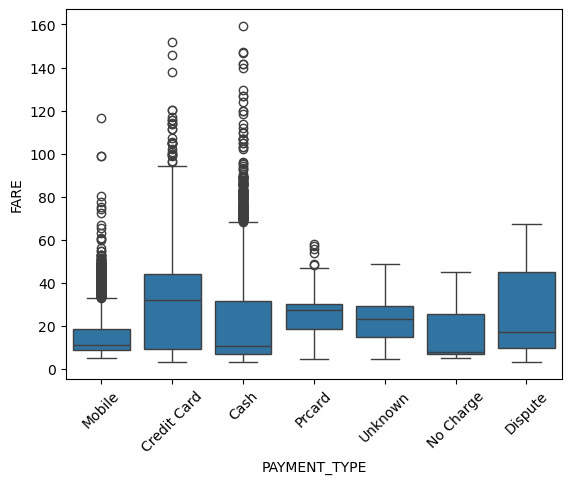

In [22]:
sns.boxplot(
    x='PAYMENT_TYPE',
    y='FARE',
    data=df
)
plt.xticks(rotation=45)
plt.show()

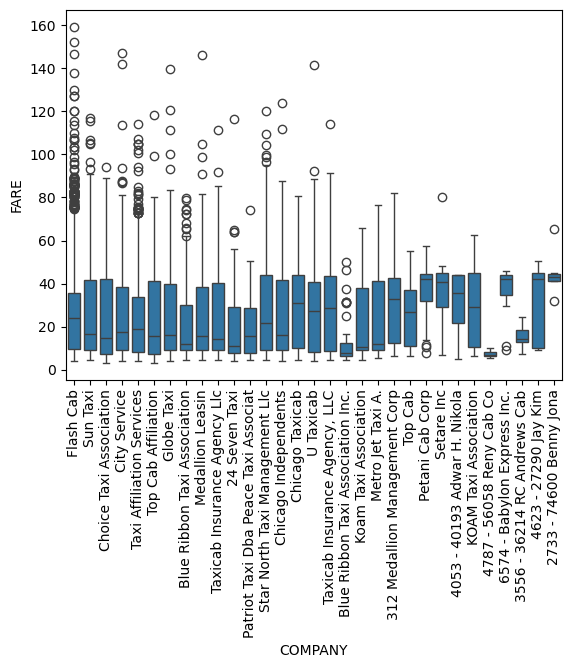

In [23]:
sns.boxplot(
    x='COMPANY',
    y='FARE',
    data=df
)
plt.xticks(rotation=90)
plt.show()

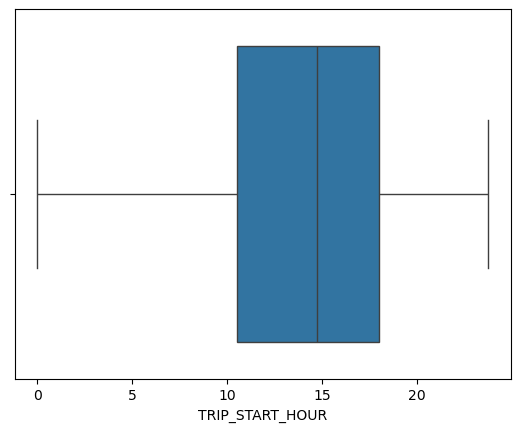

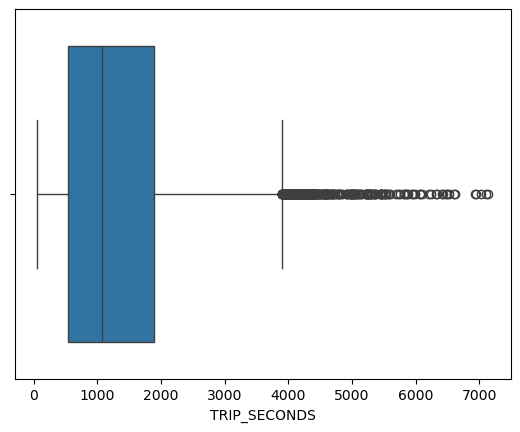

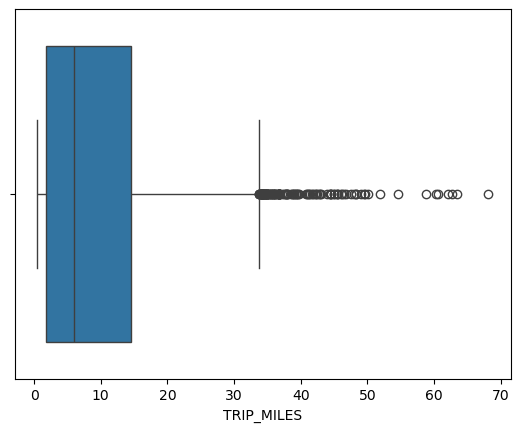

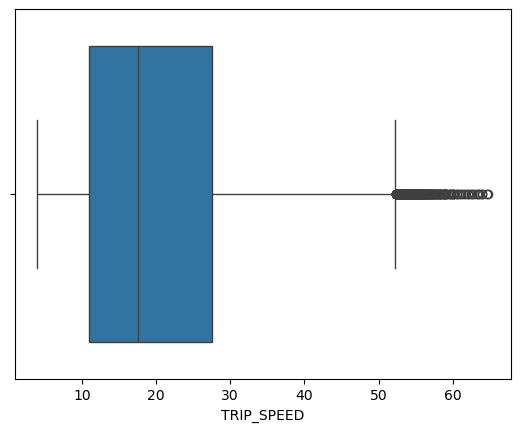

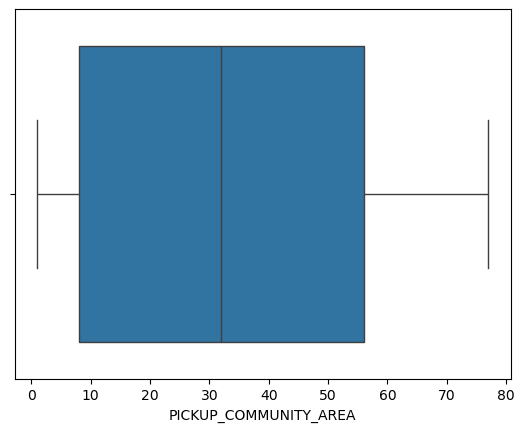

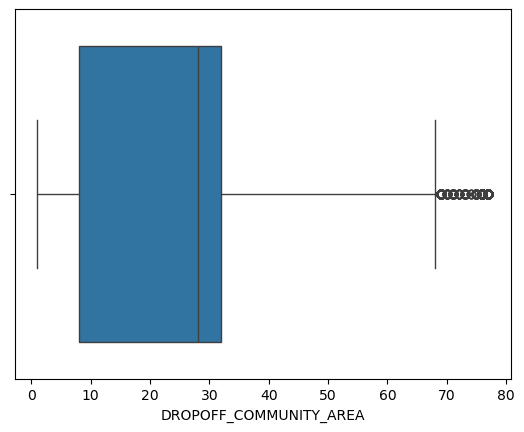

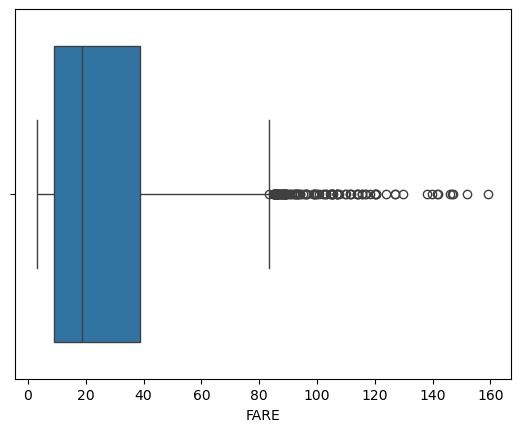

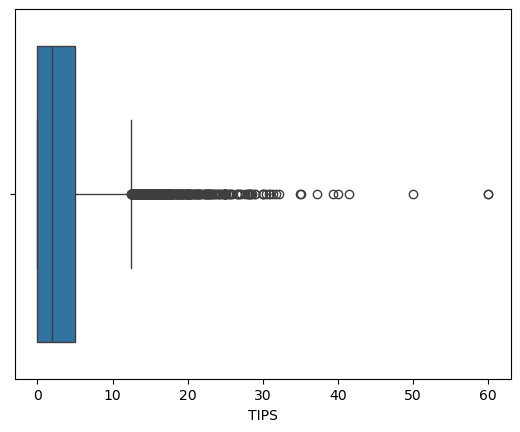

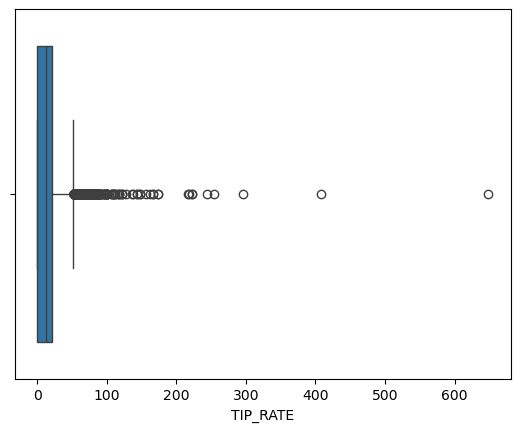

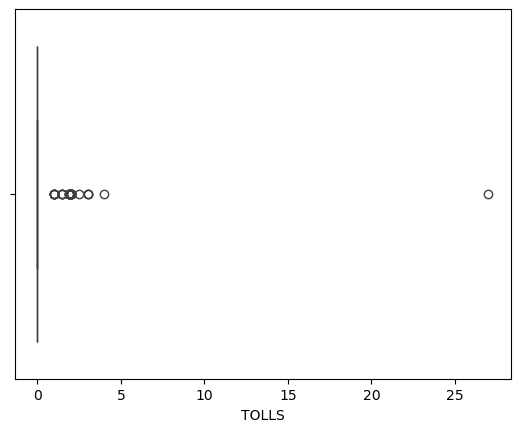

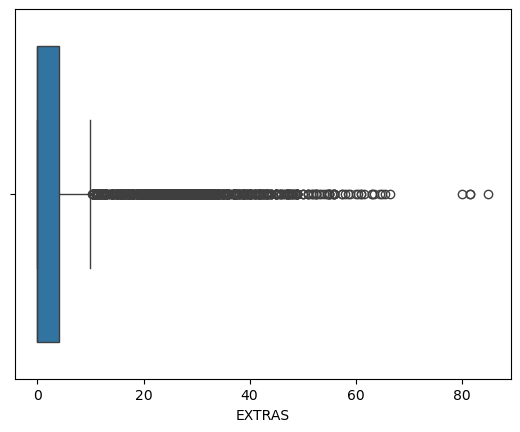

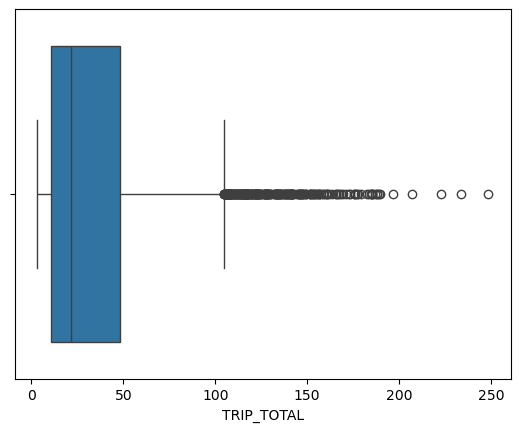

In [24]:
num_cols = df.select_dtypes(include='number')

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

In [25]:
df['TRIP_START_TIMESTAMP'] = pd.to_datetime(df['TRIP_START_TIMESTAMP'])

df['Day'] = df['TRIP_START_TIMESTAMP'].dt.day_name()

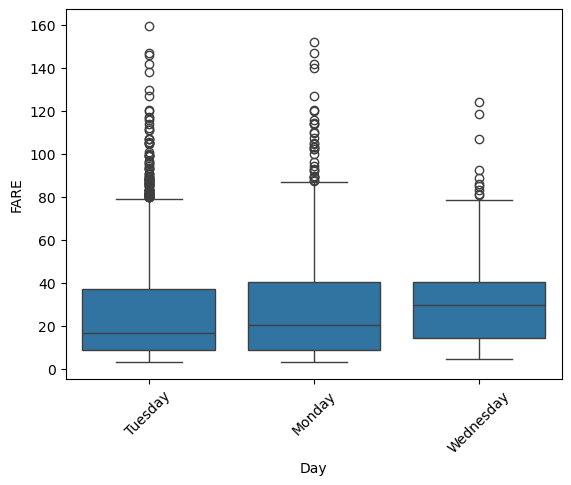

In [26]:
sns.boxplot(x='Day', y='FARE', data=df)
plt.xticks(rotation=45)
plt.show()

In [27]:
df['Day'].value_counts()

Day
Tuesday      16212
Monday       14824
Wednesday      657
Name: count, dtype: int64

In [28]:
df.drop(['TRIP_TOTAL', 'TIP_RATE', 'TIPS'], axis=1, inplace=True)

In [29]:
df

,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TOLLS,EXTRAS,PAYMENT_TYPE,COMPANY,Day
0,2022-05-17 07:15:00,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,32.0,17.0,31.99,0.0,0.0,Mobile,Flash Cab,Tuesday
1,2022-05-17 17:15:00,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,32.0,8.0,9.75,0.0,1.0,Credit Card,Flash Cab,Tuesday
2,2022-05-17 17:15:00,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,32.0,8.0,10.25,0.0,0.0,Cash,Sun Taxi,Tuesday
3,2022-05-17 18:00:00,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,32.0,24.0,23.75,0.0,1.0,Cash,Choice Taxi Association,Tuesday
4,2022-05-17 17:00:00,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,32.0,8.0,10.00,0.0,0.0,Cash,Flash Cab,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31689,2022-05-17 13:15:00,05/17/2022 1:30:00 PM,13.25,739,13.06,63.6,75.0,28.0,32.50,0.0,0.0,Prcard,Blue Ribbon Taxi Association,Tuesday
31690,2022-05-17 21:45:00,05/17/2022 10:15:00 PM,21.75,1740,30.90,63.9,76.0,28.0,44.50,0.0,27.5,Credit Card,Choice Taxi Association,Tuesday
31691,2022-05-18 03:45:00,05/18/2022 4:00:00 AM,3.75,687,12.21,64.0,22.0,28.0,30.75,0.0,0.0,Prcard,Sun Taxi,Wednesday
31692,2022-05-16 14:45:00,05/16/2022 3:30:00 PM,14.75,2040,36.60,64.6,76.0,7.0,41.75,0.0,4.0,Credit Card,"Taxicab Insurance Agency, LLC",Monday


In [30]:
df = pd.get_dummies(df, columns=['PAYMENT_TYPE', 'COMPANY', 'Day'], drop_first=False)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31693 entries, 0 to 31693
Data columns (total 52 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   TRIP_START_TIMESTAMP                          31693 non-null  datetime64[ns]
 1   TRIP_END_TIMESTAMP                            31693 non-null  object        
 2   TRIP_START_HOUR                               31693 non-null  float64       
 3   TRIP_SECONDS                                  31693 non-null  int64         
 4   TRIP_MILES                                    31693 non-null  float64       
 5   TRIP_SPEED                                    31693 non-null  float64       
 6   PICKUP_COMMUNITY_AREA                         31693 non-null  float64       
 7   DROPOFF_COMMUNITY_AREA                        31693 non-null  float64       
 8   FARE                                          31693 non-null  float64  

In [32]:
df['TRIP_END_TIMESTAMP'] = pd.to_datetime(df['TRIP_END_TIMESTAMP'])

In [33]:
df['START_HOUR'] = df['TRIP_START_TIMESTAMP'].dt.hour
df['START_DAY'] = df['TRIP_START_TIMESTAMP'].dt.day_name()
df['START_MONTH'] = df['TRIP_START_TIMESTAMP'].dt.month
df['IS_WEEKEND'] = df['START_DAY'].isin(['Saturday', 'Sunday'])

In [34]:
df.columns

Index(['TRIP_START_TIMESTAMP', 'TRIP_END_TIMESTAMP', 'TRIP_START_HOUR',
       'TRIP_SECONDS', 'TRIP_MILES', 'TRIP_SPEED', 'PICKUP_COMMUNITY_AREA',
       'DROPOFF_COMMUNITY_AREA', 'FARE', 'TOLLS', 'EXTRAS',
       'PAYMENT_TYPE_Cash', 'PAYMENT_TYPE_Credit Card', 'PAYMENT_TYPE_Dispute',
       'PAYMENT_TYPE_Mobile', 'PAYMENT_TYPE_No Charge', 'PAYMENT_TYPE_Prcard',
       'PAYMENT_TYPE_Unknown', 'COMPANY_24 Seven Taxi',
       'COMPANY_2733 - 74600 Benny Jona',
       'COMPANY_312 Medallion Management Corp',
       'COMPANY_3556 - 36214 RC Andrews Cab',
       'COMPANY_4053 - 40193 Adwar H. Nikola', 'COMPANY_4623 - 27290 Jay Kim',
       'COMPANY_4787 - 56058 Reny Cab Co',
       'COMPANY_6574 - Babylon Express Inc.',
       'COMPANY_Blue Ribbon Taxi Association',
       'COMPANY_Blue Ribbon Taxi Association Inc.',
       'COMPANY_Chicago Independents', 'COMPANY_Chicago Taxicab',
       'COMPANY_Choice Taxi Association', 'COMPANY_City Service',
       'COMPANY_Flash Cab', 'COMPANY_Globe

In [35]:
df.drop(['TRIP_SPEED', 'START_DAY'], axis=1, inplace=True)

In [36]:
df.columns

Index(['TRIP_START_TIMESTAMP', 'TRIP_END_TIMESTAMP', 'TRIP_START_HOUR',
       'TRIP_SECONDS', 'TRIP_MILES', 'PICKUP_COMMUNITY_AREA',
       'DROPOFF_COMMUNITY_AREA', 'FARE', 'TOLLS', 'EXTRAS',
       'PAYMENT_TYPE_Cash', 'PAYMENT_TYPE_Credit Card', 'PAYMENT_TYPE_Dispute',
       'PAYMENT_TYPE_Mobile', 'PAYMENT_TYPE_No Charge', 'PAYMENT_TYPE_Prcard',
       'PAYMENT_TYPE_Unknown', 'COMPANY_24 Seven Taxi',
       'COMPANY_2733 - 74600 Benny Jona',
       'COMPANY_312 Medallion Management Corp',
       'COMPANY_3556 - 36214 RC Andrews Cab',
       'COMPANY_4053 - 40193 Adwar H. Nikola', 'COMPANY_4623 - 27290 Jay Kim',
       'COMPANY_4787 - 56058 Reny Cab Co',
       'COMPANY_6574 - Babylon Express Inc.',
       'COMPANY_Blue Ribbon Taxi Association',
       'COMPANY_Blue Ribbon Taxi Association Inc.',
       'COMPANY_Chicago Independents', 'COMPANY_Chicago Taxicab',
       'COMPANY_Choice Taxi Association', 'COMPANY_City Service',
       'COMPANY_Flash Cab', 'COMPANY_Globe Taxi',
      

In [37]:
company_cols = [col for col in df.columns if col.startswith('COMPANY_')]

top_companies = df[company_cols].sum().sort_values(ascending=False).head(10).index

df = df.drop(columns=[col for col in company_cols if col not in top_companies])

In [38]:
df.columns

Index(['TRIP_START_TIMESTAMP', 'TRIP_END_TIMESTAMP', 'TRIP_START_HOUR',
       'TRIP_SECONDS', 'TRIP_MILES', 'PICKUP_COMMUNITY_AREA',
       'DROPOFF_COMMUNITY_AREA', 'FARE', 'TOLLS', 'EXTRAS',
       'PAYMENT_TYPE_Cash', 'PAYMENT_TYPE_Credit Card', 'PAYMENT_TYPE_Dispute',
       'PAYMENT_TYPE_Mobile', 'PAYMENT_TYPE_No Charge', 'PAYMENT_TYPE_Prcard',
       'PAYMENT_TYPE_Unknown', 'COMPANY_Chicago Independents',
       'COMPANY_City Service', 'COMPANY_Flash Cab', 'COMPANY_Globe Taxi',
       'COMPANY_Medallion Leasin', 'COMPANY_Star North Taxi Management Llc',
       'COMPANY_Sun Taxi', 'COMPANY_Taxi Affiliation Services',
       'COMPANY_Taxicab Insurance Agency Llc',
       'COMPANY_Taxicab Insurance Agency, LLC', 'Day_Monday', 'Day_Tuesday',
       'Day_Wednesday', 'START_HOUR', 'START_MONTH', 'IS_WEEKEND'],
      dtype='object')

In [39]:
df.corr(numeric_only=True)['FARE'].sort_values()

PAYMENT_TYPE_Mobile                      -0.157221
PAYMENT_TYPE_Cash                        -0.144853
Day_Tuesday                              -0.043319
TRIP_START_HOUR                          -0.037764
START_HOUR                               -0.037488
COMPANY_Taxi Affiliation Services        -0.032793
PAYMENT_TYPE_Unknown                     -0.022906
COMPANY_Taxicab Insurance Agency Llc     -0.013251
COMPANY_Medallion Leasin                 -0.010487
PAYMENT_TYPE_No Charge                   -0.010118
COMPANY_City Service                     -0.008738
COMPANY_Globe Taxi                       -0.008072
COMPANY_Chicago Independents             -0.005035
PAYMENT_TYPE_Dispute                      0.002899
COMPANY_Sun Taxi                          0.003127
PAYMENT_TYPE_Prcard                       0.011274
TOLLS                                     0.019363
Day_Monday                                0.030017
COMPANY_Star North Taxi Management Llc    0.033443
COMPANY_Taxicab Insurance Agenc

In [40]:
df.drop('START_HOUR', axis=1, inplace=True)

In [41]:
df.drop('DROPOFF_COMMUNITY_AREA', axis=1, inplace=True)

In [42]:
df['PICKUP_COMMUNITY_AREA'].corr(df['FARE'])

0.5092543264608196

In [43]:
df['PICKUP_COMMUNITY_AREA'].value_counts()

PICKUP_COMMUNITY_AREA
32.0    8251
8.0     6494
76.0    6273
28.0    2672
6.0     1052
        ... 
64.0       5
63.0       5
65.0       3
74.0       3
18.0       3
Name: count, Length: 77, dtype: int64

In [44]:
freq = df['PICKUP_COMMUNITY_AREA'].value_counts()

df['PICKUP_AREA_FREQ'] = df['PICKUP_COMMUNITY_AREA'].map(freq)

In [45]:
df

,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,PICKUP_COMMUNITY_AREA,FARE,TOLLS,EXTRAS,PAYMENT_TYPE_Cash,...,COMPANY_Sun Taxi,COMPANY_Taxi Affiliation Services,COMPANY_Taxicab Insurance Agency Llc,"COMPANY_Taxicab Insurance Agency, LLC",Day_Monday,Day_Tuesday,Day_Wednesday,START_MONTH,IS_WEEKEND,PICKUP_AREA_FREQ
0,2022-05-17 07:15:00,2022-05-17 07:45:00,7.25,2341,2.57,32.0,31.99,0.0,0.0,False,...,False,False,False,False,False,True,False,5,False,8251
1,2022-05-17 17:15:00,2022-05-17 17:30:00,17.25,1074,1.18,32.0,9.75,0.0,1.0,False,...,False,False,False,False,False,True,False,5,False,8251
2,2022-05-17 17:15:00,2022-05-17 17:30:00,17.25,1173,1.29,32.0,10.25,0.0,0.0,True,...,True,False,False,False,False,True,False,5,False,8251
3,2022-05-17 18:00:00,2022-05-17 19:00:00,18.00,3360,3.70,32.0,23.75,0.0,1.0,True,...,False,False,False,False,False,True,False,5,False,8251
4,2022-05-17 17:00:00,2022-05-17 17:30:00,17.00,1044,1.15,32.0,10.00,0.0,0.0,True,...,False,False,False,False,False,True,False,5,False,8251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31689,2022-05-17 13:15:00,2022-05-17 13:30:00,13.25,739,13.06,75.0,32.50,0.0,0.0,False,...,False,False,False,False,False,True,False,5,False,54
31690,2022-05-17 21:45:00,2022-05-17 22:15:00,21.75,1740,30.90,76.0,44.50,0.0,27.5,False,...,False,False,False,False,False,True,False,5,False,6273
31691,2022-05-18 03:45:00,2022-05-18 04:00:00,3.75,687,12.21,22.0,30.75,0.0,0.0,False,...,True,False,False,False,False,False,True,5,False,121
31692,2022-05-16 14:45:00,2022-05-16 15:30:00,14.75,2040,36.60,76.0,41.75,0.0,4.0,False,...,False,False,False,True,True,False,False,5,False,6273


In [46]:
df.columns

Index(['TRIP_START_TIMESTAMP', 'TRIP_END_TIMESTAMP', 'TRIP_START_HOUR',
       'TRIP_SECONDS', 'TRIP_MILES', 'PICKUP_COMMUNITY_AREA', 'FARE', 'TOLLS',
       'EXTRAS', 'PAYMENT_TYPE_Cash', 'PAYMENT_TYPE_Credit Card',
       'PAYMENT_TYPE_Dispute', 'PAYMENT_TYPE_Mobile', 'PAYMENT_TYPE_No Charge',
       'PAYMENT_TYPE_Prcard', 'PAYMENT_TYPE_Unknown',
       'COMPANY_Chicago Independents', 'COMPANY_City Service',
       'COMPANY_Flash Cab', 'COMPANY_Globe Taxi', 'COMPANY_Medallion Leasin',
       'COMPANY_Star North Taxi Management Llc', 'COMPANY_Sun Taxi',
       'COMPANY_Taxi Affiliation Services',
       'COMPANY_Taxicab Insurance Agency Llc',
       'COMPANY_Taxicab Insurance Agency, LLC', 'Day_Monday', 'Day_Tuesday',
       'Day_Wednesday', 'START_MONTH', 'IS_WEEKEND', 'PICKUP_AREA_FREQ'],
      dtype='object')

In [47]:
df.drop(['TRIP_START_TIMESTAMP', 'TRIP_END_TIMESTAMP'], axis=1, inplace=True)

In [48]:
df.drop(['IS_WEEKEND'], axis=1, inplace=True)

In [49]:
df.columns

Index(['TRIP_START_HOUR', 'TRIP_SECONDS', 'TRIP_MILES',
       'PICKUP_COMMUNITY_AREA', 'FARE', 'TOLLS', 'EXTRAS', 'PAYMENT_TYPE_Cash',
       'PAYMENT_TYPE_Credit Card', 'PAYMENT_TYPE_Dispute',
       'PAYMENT_TYPE_Mobile', 'PAYMENT_TYPE_No Charge', 'PAYMENT_TYPE_Prcard',
       'PAYMENT_TYPE_Unknown', 'COMPANY_Chicago Independents',
       'COMPANY_City Service', 'COMPANY_Flash Cab', 'COMPANY_Globe Taxi',
       'COMPANY_Medallion Leasin', 'COMPANY_Star North Taxi Management Llc',
       'COMPANY_Sun Taxi', 'COMPANY_Taxi Affiliation Services',
       'COMPANY_Taxicab Insurance Agency Llc',
       'COMPANY_Taxicab Insurance Agency, LLC', 'Day_Monday', 'Day_Tuesday',
       'Day_Wednesday', 'START_MONTH', 'PICKUP_AREA_FREQ'],
      dtype='object')

In [50]:
df.drop('PICKUP_COMMUNITY_AREA', axis=1, inplace=True)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31693 entries, 0 to 31693
Data columns (total 28 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   TRIP_START_HOUR                         31693 non-null  float64
 1   TRIP_SECONDS                            31693 non-null  int64  
 2   TRIP_MILES                              31693 non-null  float64
 3   FARE                                    31693 non-null  float64
 4   TOLLS                                   31693 non-null  float64
 5   EXTRAS                                  31693 non-null  float64
 6   PAYMENT_TYPE_Cash                       31693 non-null  bool   
 7   PAYMENT_TYPE_Credit Card                31693 non-null  bool   
 8   PAYMENT_TYPE_Dispute                    31693 non-null  bool   
 9   PAYMENT_TYPE_Mobile                     31693 non-null  bool   
 10  PAYMENT_TYPE_No Charge                  31693 non-null  bool   

In [52]:
X = df.drop('FARE', axis=1)
y = df['FARE']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [54]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [56]:
y_pred_lr = lr.predict(X_test_scaled)

In [57]:
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression MAE: 1.2286301647003706
Linear Regression RMSE: 3.167557945347122


In [58]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [59]:
y_pred_rf = rf.predict(X_test)

In [60]:
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest MAE: 0.9696780321554398
Random Forest RMSE: 3.115623370539335


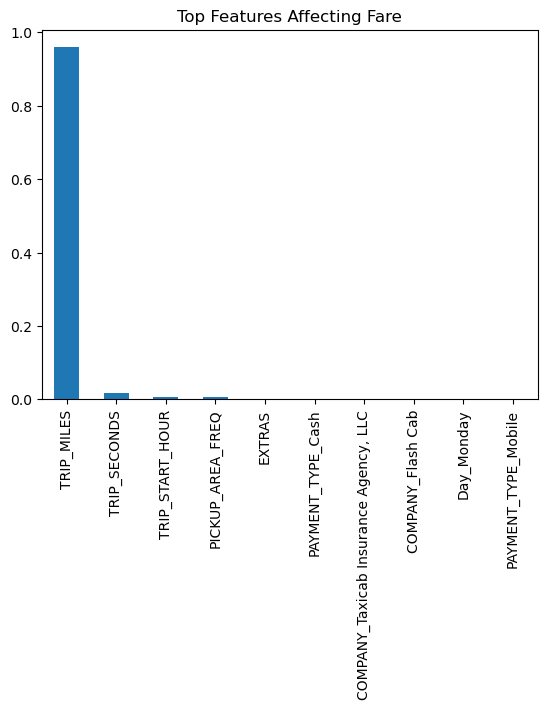

In [61]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

top_features.plot(kind='bar')
plt.title("Top Features Affecting Fare")
plt.show()

In [62]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
})

results

,Model,MAE,RMSE
0,Linear Regression,1.228630,3.167558
1,Random Forest,0.969678,3.115623
